In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from nnsight import LanguageModel, util

def _find_delimiter_token_index(tokenizer, text, delimiter=","):
    """Tokenizer-agnostic delimiter lookup using character offsets."""
    char_idx = text.find(delimiter)
    if char_idx == -1:
        raise ValueError(f"Delimiter '{delimiter}' not found in text.")

    encoded = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    offsets = encoded.get("offset_mapping")
    if offsets is None:
        raise ValueError("Tokenizer did not return offset mapping.")

    for tok_idx, (start, end) in enumerate(offsets):
        # Skip special tokens that often map to (0, 0)
        if start == end:
            continue
        if start <= char_idx < end:
            return tok_idx

    raise ValueError(f"Could not map delimiter '{delimiter}' to token index.")


/home/40455223@eeecs.qub.ac.uk/idiom_comp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:

import json
import numpy as np
import torch

path = "attention_head_qwen_v2.npz"
data = np.load(path)

acc = torch.from_numpy(data["accumulated_results"]).float()   # shape: [layers, heads]
n = int(data["total_combinations"])

avg = acc / n
n_layers, n_heads = avg.shape
def top_heads(k):
    vals, idxs = torch.topk(avg.flatten(), k)
    out = []
    for i in idxs.tolist():
        layer = i // n_heads
        head = i % n_heads
        out.append([layer, head])  # save as [layer, head]
    return out

for k in [67, 168]:
    out = top_heads(k)
    with open(f"top_{k}_heads_mistral_from_accumulator.json", "w") as f:
        json.dump(out, f, indent=2)
    print(f"\nTop {k} heads:")
    print(out)


Top 67 heads:
[[0, 0], [0, 3], [18, 7], [0, 10], [18, 8], [15, 26], [2, 12], [0, 23], [3, 21], [14, 21], [19, 21], [20, 1], [0, 1], [3, 7], [8, 1], [7, 22], [18, 9], [24, 19], [3, 4], [21, 22], [7, 14], [15, 8], [18, 26], [12, 22], [9, 21], [20, 3], [0, 16], [2, 11], [13, 22], [9, 17], [15, 1], [18, 15], [9, 25], [7, 16], [17, 6], [6, 7], [5, 2], [23, 27], [13, 19], [15, 5], [0, 21], [12, 10], [7, 7], [19, 12], [13, 1], [9, 26], [22, 23], [6, 10], [21, 13], [9, 7], [19, 0], [3, 2], [0, 11], [17, 9], [14, 26], [9, 8], [17, 25], [18, 5], [18, 20], [4, 21], [21, 4], [19, 15], [16, 18], [20, 9], [5, 12], [11, 19], [19, 2]]

Top 168 heads:
[[0, 0], [0, 3], [18, 7], [0, 10], [18, 8], [15, 26], [2, 12], [0, 23], [3, 21], [14, 21], [19, 21], [20, 1], [0, 1], [3, 7], [8, 1], [7, 22], [18, 9], [24, 19], [3, 4], [21, 22], [7, 14], [15, 8], [18, 26], [12, 22], [9, 21], [20, 3], [0, 16], [2, 11], [13, 22], [9, 17], [15, 1], [18, 15], [9, 25], [7, 16], [17, 6], [6, 7], [5, 2], [23, 27], [13, 19], [

In [16]:
path = "residual_stream_qwen_v2.npz"
# load the npz file
data = np.load(path)
# print the keys
print(data.keys())
total_results = data["total_results"]
counts = data["counts"]


KeysView(NpzFile 'residual_stream_qwen_v2.npz' with keys: total_results, counts)


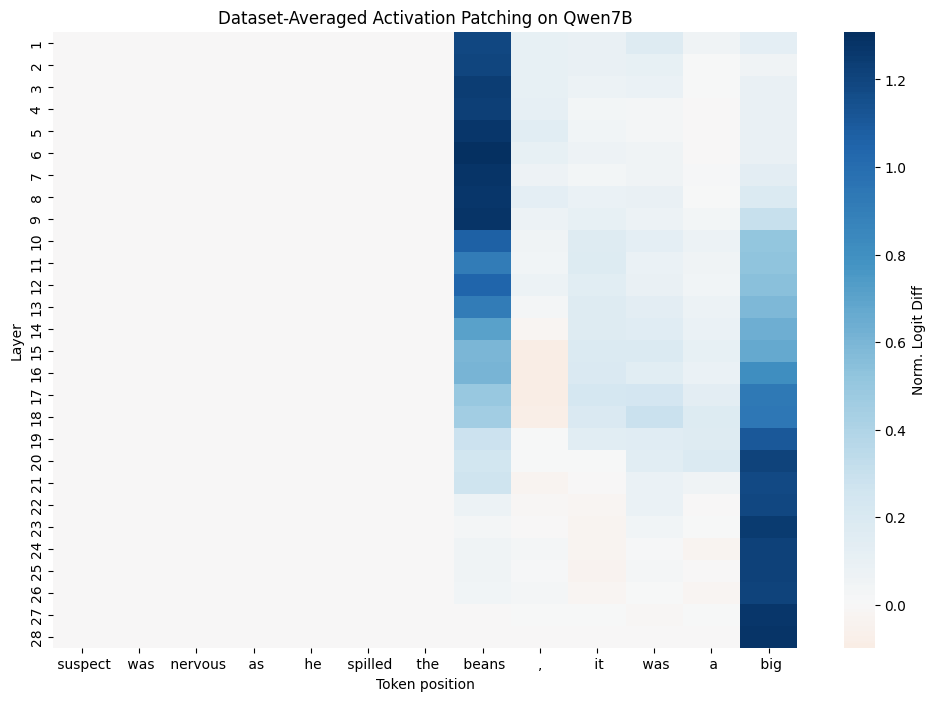

In [18]:
model = LanguageModel("Qwen/Qwen2.5-7B")
N_LAYERS = 28
avg_results = np.divide(total_results, counts, out=np.zeros_like(total_results), where=counts!=0)
# Use first idiom's first pair for labels
prompt_idiom = "The suspect was nervous as he spilled the beans, it was a big"
        
idiom_tokens = model.tokenizer(prompt_idiom, return_tensors="pt")["input_ids"][0]
try:
    and_token_idx = _find_delimiter_token_index(model.tokenizer, prompt_idiom, delimiter=",")
    
except ValueError:
    print("Error finding delimiter token index")


label_start = max(0, and_token_idx - 8)
label_end = min(len(idiom_tokens), and_token_idx + 5)
labels = [model.tokenizer.decode(token) for token in idiom_tokens[label_start:label_end]]
# Calculate the absolute maximum to make the scale symmetric
y_labels = list(range(1, N_LAYERS + 1))
plt.figure(figsize=(12, 8))
sns.heatmap(
            avg_results,
            xticklabels=labels,
            yticklabels=y_labels,
            cmap="RdBu",
            cbar_kws={'label': 'Norm. Logit Diff'},
            center=0
        )
plt.xlabel("Token position")
plt.ylabel("Layer")
plt.title(f"Dataset-Averaged Activation Patching on Qwen7B")
plt.savefig(f"averaged_patching_results_qwen7b.png")
plt.savefig(f"averaged_patching_results_qwen7b.eps")
plt.gca() # Often helpful to have Layer 0 at the bottom
plt.show()